# Tracing Wildfire Smoke from Source to City: Chicago, July 2026

**Authors:** Scott Collis and Claude (Anthropic)

In July 2026, wildfire smoke from Canadian fires degraded air quality across the
US Midwest, pushing Chicago into the *Hazardous* PM$_{2.5}$ range. This notebook
traces the smoke from **source to surface impact** by combining two open datasets:

- **NOAA Hazard Mapping System (HMS)** — daily satellite-analyzed *fire detections*
  and *smoke-plume polygons* (Light / Medium / Heavy density).
- **AirNow API** — real-time surface PM$_{2.5}$ from EPA / state / provincial monitors.

We build a single figure: a regional map showing the Ontario fire source, the smoke
plumes draped across the Great Lakes, and surface PM$_{2.5}$ stations colored by EPA
category — plus three time-series panels sampled *along the plume's length* to show
the smoke propagating downwind from Lake Superior to Chicago.

> **Reproducibility note.** The observation window and HMS date are hard-coded to the
> event (2026-07-16) so the notebook reproduces the same figure whenever it is run.
> The AirNow API key is read from the `AIRNOW_API` environment variable — set it
> before running: `export AIRNOW_API=your-key` (free key from
> https://docs.airnowapi.org/).

## 1. Setup and configuration

In [2]:
import os
import json
import zipfile
import urllib.request
import urllib.parse
from collections import defaultdict
from datetime import datetime, timezone, timedelta
from zoneinfo import ZoneInfo

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
from shapely.geometry import box as sbox

import warnings
warnings.filterwarnings("ignore")

# --- Event configuration (pinned so the notebook reproduces this event) ---
HMS_DATE = "20260716"                 # NOAA HMS analysis date
END_DATE = "2026-07-16T17"            # end of the AirNow 24 h window (UTC hour)
WINDOW_HOURS = 24
CENTRAL = ZoneInfo("America/Chicago") # for local-time axes

# AirNow API key from environment (never hard-code credentials)
AIRNOW_API = os.environ["AIRNOW_API"]

# Regional extent: upper Midwest + Ontario source region [lon_min, lon_max, lat_min, lat_max]
REG = [-98, -78, 40, 52]

start_dt = datetime.strptime(END_DATE, "%Y-%m-%dT%H").replace(tzinfo=timezone.utc) - timedelta(hours=WINDOW_HOURS - 1)
START_DATE = start_dt.strftime("%Y-%m-%dT%H")
print("AirNow window:", START_DATE, "->", END_DATE, "UTC")

AirNow window: 2026-07-15T18 -> 2026-07-16T17 UTC


## 2. Download NOAA HMS fire detections and smoke plumes

HMS publishes daily shapefiles at `satepsanone.nesdis.noaa.gov`. We grab the
fire-point and smoke-polygon archives for the event date and unzip them locally.

In [4]:
HMS_BASE = "https://satepsanone.nesdis.noaa.gov/pub/FIRE/web/HMS"
os.makedirs("hms", exist_ok=True)

hms_urls = {
    "smoke": f"{HMS_BASE}/Smoke_Polygons/Shapefile/{HMS_DATE[:4]}/{HMS_DATE[4:6]}/hms_smoke{HMS_DATE}.zip",
    "fire":  f"{HMS_BASE}/Fire_Points/Shapefile/{HMS_DATE[:4]}/{HMS_DATE[4:6]}/hms_fire{HMS_DATE}.zip",
}
for kind, url in hms_urls.items():
    dst = f"hms/{kind}.zip"
    if not os.path.exists(dst):
        urllib.request.urlretrieve(url, dst)
    with zipfile.ZipFile(dst) as z:
        z.extractall(f"hms/{kind}")
    print(kind, "->", os.path.getsize(dst), "bytes")

smoke_recs = list(shpreader.Reader(f"hms/smoke/hms_smoke{HMS_DATE}.shp").records())
fire_recs  = list(shpreader.Reader(f"hms/fire/hms_fire{HMS_DATE}.shp").records())
print(f"{len(smoke_recs)} smoke polygons, {len(fire_recs):,} fire detections (continent-wide)")

smoke -> 27458 bytes
fire -> 1042570 bytes
35 smoke polygons, 39,498 fire detections (continent-wide)


## 3. Quantify the source region

Restrict the fire detections to our regional window and split them roughly by
latitude to confirm the source is the Ontario fires (north of 48°N) rather than
the handful of detections in northern Minnesota.

In [6]:
reg_box = sbox(REG[0], REG[2], REG[1], REG[3])

reg_fires = [(r.geometry.x, r.geometry.y) for r in fire_recs
             if REG[0] <= r.geometry.x <= REG[1] and REG[2] <= r.geometry.y <= REG[3]]
fx = np.array([p[0] for p in reg_fires])
fy = np.array([p[1] for p in reg_fires])

n_ontario = int((fy > 48.0).sum())
n_minn    = int(((fy <= 48.0) & (fx > -97) & (fx < -89)).sum())
print(f"Fire detections in region: {len(reg_fires):,}")
print(f"  north of 48N (Ontario / Canada): {n_ontario:,}")
print(f"  northern-Minnesota band:         {n_minn}")

for dens in ["Light", "Medium", "Heavy"]:
    n = sum(1 for r in smoke_recs
            if str(r.attributes.get("Density")) == dens and r.geometry.intersects(reg_box))
    print(f"  {dens:6s} smoke polygons over region: {n}")

Fire detections in region: 17,997
  north of 48N (Ontario / Canada): 17,972
  northern-Minnesota band:         19
  Light  smoke polygons over region: 1
  Medium smoke polygons over region: 1
  Heavy  smoke polygons over region: 3


## 4. Pull surface PM$_{2.5}$ from AirNow

A small helper wraps the AirNow `aq/data` endpoint. We pull the latest hour across
the whole region for the map, then 24 h series for three sites strung along the
plume axis.

In [8]:
def airnow_data(bbox, start, end, param="PM25"):
    """Query the AirNow aq/data endpoint. bbox = 'minLon,minLat,maxLon,maxLat'."""
    q = urllib.parse.urlencode({
        "startDate": start, "endDate": end, "parameters": param, "BBOX": bbox,
        "dataType": "B", "format": "application/json",
        "verbose": 1, "monitorType": 2, "API_KEY": AIRNOW_API,
    })
    with urllib.request.urlopen("https://www.airnowapi.org/aq/data/?" + q, timeout=90) as r:
        return json.load(r)

# Latest-hour PM2.5 across the whole region (for the map)
reg_bbox = f"{REG[0]},{REG[2]},{REG[1]},{REG[3]}"
reg_raw = airnow_data(reg_bbox, END_DATE, END_DATE)
by_site = defaultdict(list)
for rec in reg_raw:
    if rec["Value"] is not None and rec["Value"] >= 0:
        by_site[(rec["Latitude"], rec["Longitude"], rec["SiteName"])].append(rec["Value"])
reg_stations = [(lat, lon, name, vals[-1]) for (lat, lon, name), vals in by_site.items()]
sv = np.array([s[3] for s in reg_stations])
print(f"{len(reg_stations)} AirNow stations | PM2.5 {sv.min():.0f}-{sv.max():.0f}, median {np.median(sv):.0f}")

210 AirNow stations | PM2.5 1-460, median 161


In [9]:
# Three sites along the plume axis: upstream (Lake Superior) -> mid -> downwind (Chicago)
PLUME_SITES = {
    "Duluth, MN":    "-92.3,46.6,-91.9,47.0",
    "Milwaukee, WI": "-88.05,42.9,-87.85,43.15",
    "Chicago, IL":   "-88.1,41.6,-87.3,42.15",
}

def best_series(bbox, start, end):
    """Return (site_name, (lat, lon), [(UTC, value), ...]) for the most complete site in bbox."""
    raw = airnow_data(bbox, start, end)
    per, coords = defaultdict(list), {}
    for rec in raw:
        if rec["Value"] is not None and rec["Value"] >= 0:
            per[rec["SiteName"]].append((rec["UTC"], rec["Value"]))
            coords[rec["SiteName"]] = (rec["Latitude"], rec["Longitude"])
    site = max(per, key=lambda s: len(per[s]))
    return site, coords[site], sorted(per[site])

plume_series = {city: best_series(bbox, START_DATE, END_DATE) for city, bbox in PLUME_SITES.items()}
for city, (site, (la, lo), recs) in plume_series.items():
    arr = next((u for u, v in recs if v > 55), None)  # first hour above "Unhealthy"
    print(f"{city:14s} [{site:32s}] peak {max(v for _,v in recs):5.0f}  "
          f"arrival>55: {arr[11:] if arr else '--'} UTC")

Duluth, MN     [West Duluth                     ] peak   560  arrival>55: 18:00 UTC
Milwaukee, WI  [Milwaukee College Ave-Near Road ] peak   367  arrival>55: 01:00 UTC
Chicago, IL    [SCHILPRK                        ] peak   236  arrival>55: 07:00 UTC


## 5. EPA PM$_{2.5}$ color scale

Standard EPA AQI breakpoints for 24 h PM$_{2.5}$, used both for the station colors
and the shaded bands behind the time series.

In [11]:
EPA_BANDS = [
    (0.0,   12.0,  "#2c7fb8", "Good"),
    (12.0,  35.4,  "#fdae61", "Moderate"),
    (35.4,  55.4,  "#d7301f", "Unhealthy (SG)"),
    (55.4,  150.4, "#7a0177", "Unhealthy"),
    (150.4, 1e4,   "#4d004b", "Hazardous"),
]
def pm_color(v):
    for lo, hi, c, _ in EPA_BANDS:
        if v <= hi:
            return c
    return EPA_BANDS[-1][2]

SMOKE_COLORS = {"Light": "#ffe08a", "Medium": "#f59e3b", "Heavy": "#7a2b12"}
SMOKE_ALPHA  = {"Light": 0.12,      "Medium": 0.18,      "Heavy": 0.28}

## 6. The composite figure

Top: regional map with the Ontario fire cluster, graded smoke plumes, and AirNow
surface stations colored by EPA category. Bottom: three PM$_{2.5}$ time series along
the plume, sharing a common y-axis with EPA color bands. The staircase in arrival
times — Duluth first, then Milwaukee, then Chicago — is the surface signature of the
plume sweeping southeast from the source.

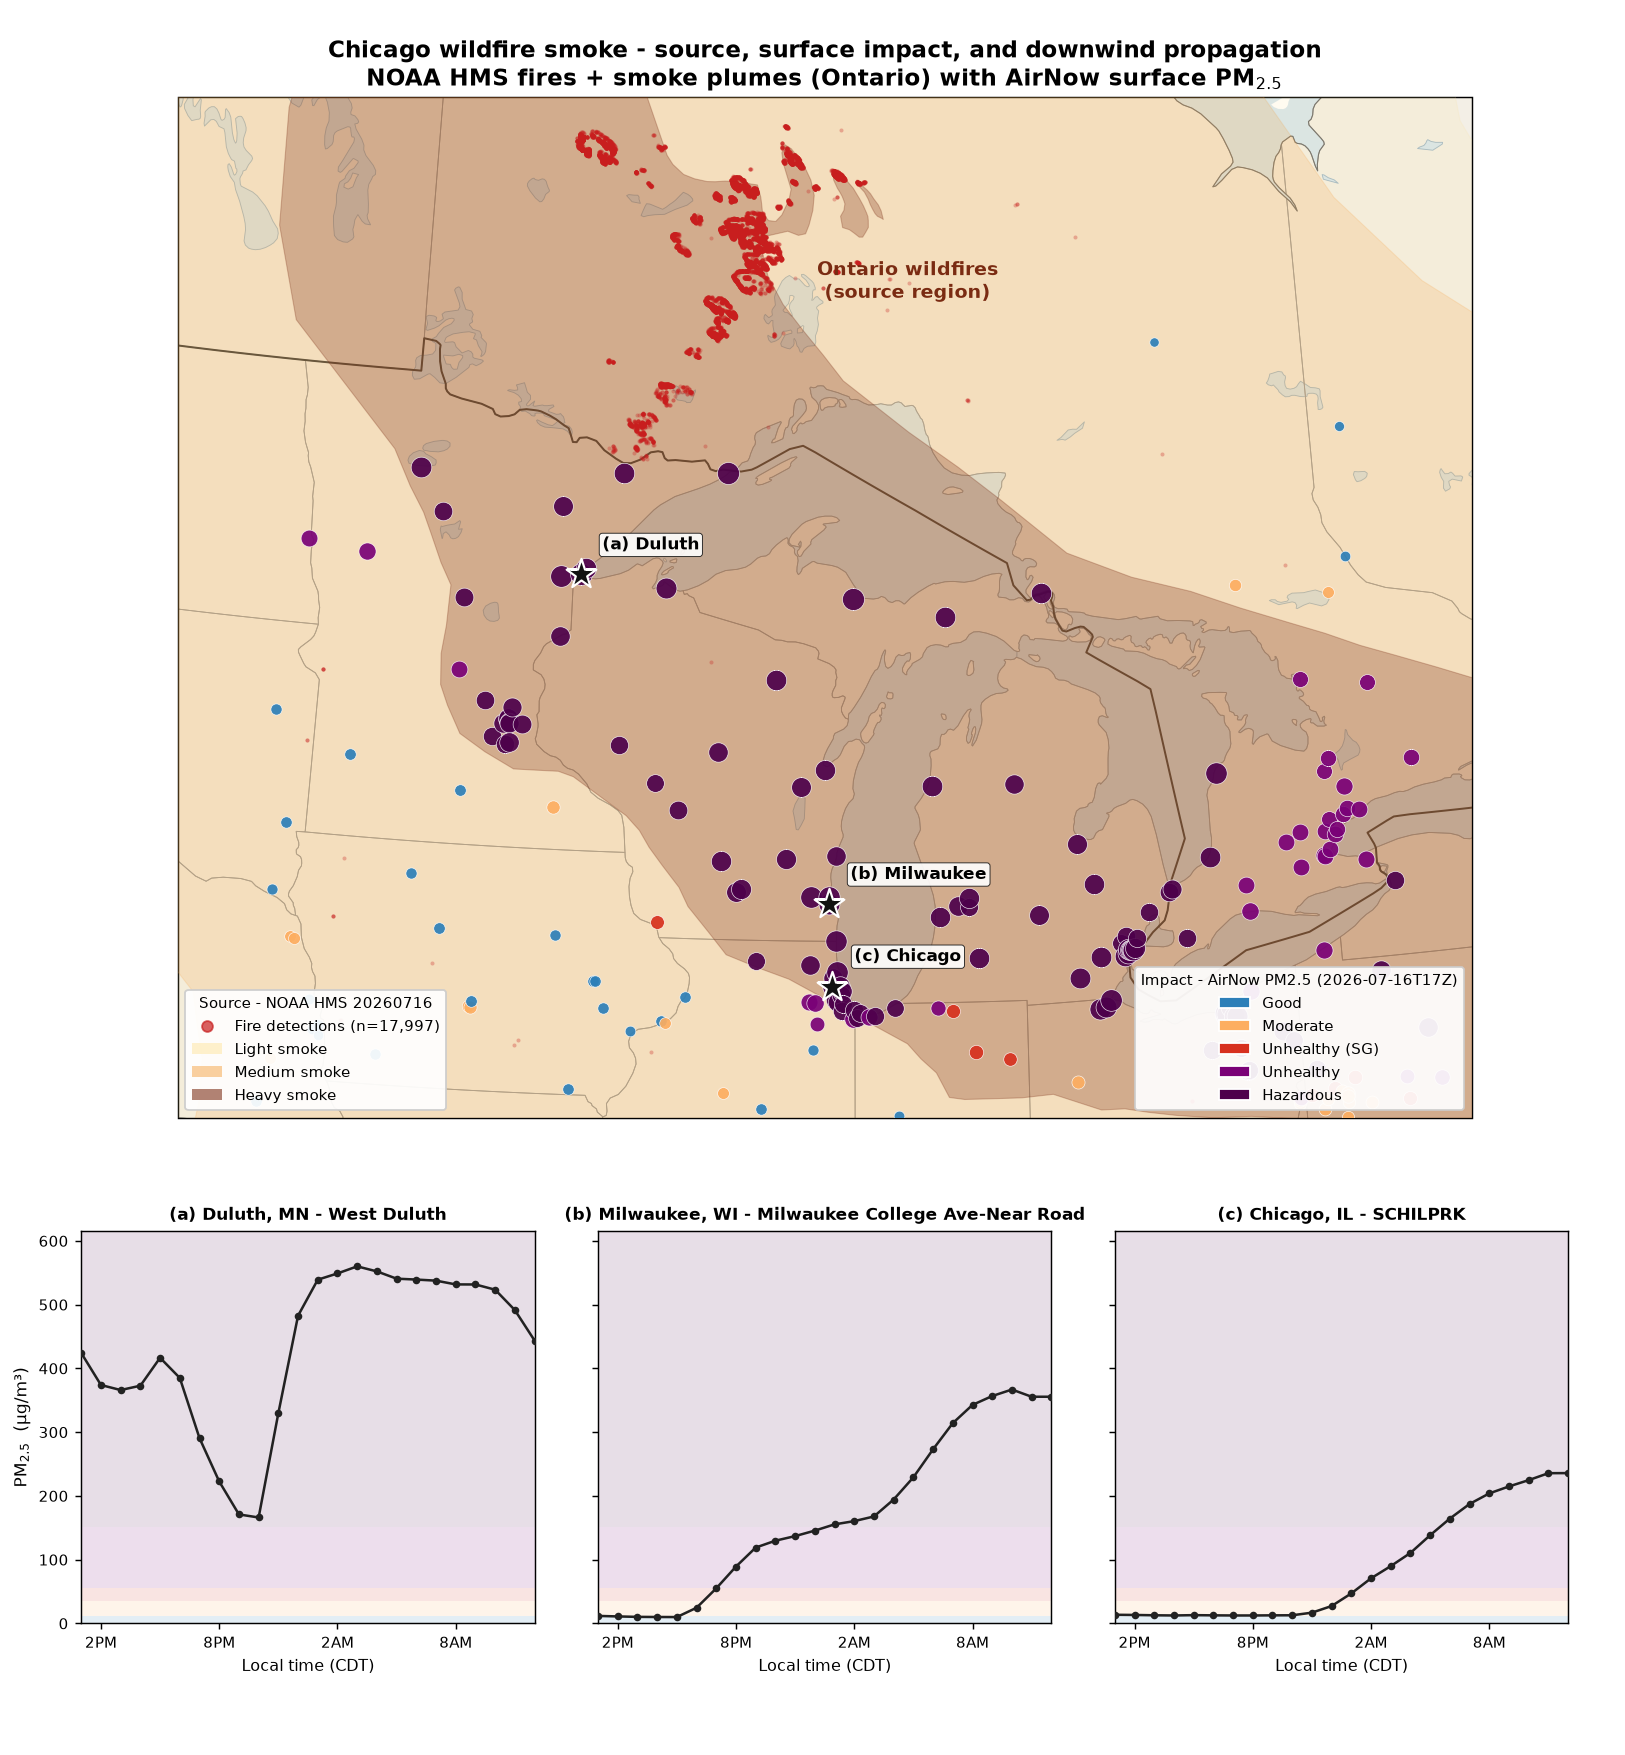

In [13]:
proj = ccrs.LambertConformal(central_longitude=-88, central_latitude=46)
fig = plt.figure(figsize=(12.5, 13.5))
gs = fig.add_gridspec(2, 3, height_ratios=[2.6, 1.0], hspace=0.16, wspace=0.14,
                      left=0.05, right=0.965, top=0.945, bottom=0.075)

# ---- Map ----
ax = fig.add_subplot(gs[0, :], projection=proj)
ax.set_extent(REG, crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND.with_scale("50m"),  facecolor="#f3efe6", zorder=0)
ax.add_feature(cfeature.OCEAN.with_scale("50m"), facecolor="#d7e6ef", zorder=0)
ax.add_feature(cfeature.LAKES.with_scale("50m"), facecolor="#d7e6ef",
               edgecolor="#9fb8c8", linewidth=0.5, zorder=1)
ax.add_feature(cfeature.STATES.with_scale("50m"),  edgecolor="#9a9a9a", linewidth=0.5, zorder=2)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), edgecolor="#333333", linewidth=1.1, zorder=2.5)
ax.coastlines("50m", color="#6a6a6a", linewidth=0.6, zorder=2)

for dens in ["Light", "Medium", "Heavy"]:
    geoms = [r.geometry for r in smoke_recs if str(r.attributes.get("Density")) == dens]
    ax.add_geometries(geoms, ccrs.PlateCarree(), facecolor=SMOKE_COLORS[dens],
                      edgecolor=SMOKE_COLORS[dens], linewidth=0.6,
                      alpha=SMOKE_ALPHA[dens], zorder=3)

ax.scatter(fx, fy, s=5, c="#c81e1e", marker="o", transform=ccrs.PlateCarree(),
           zorder=4, alpha=0.30, linewidths=0)
for lat, lon, name, v in reg_stations:
    ax.scatter(lon, lat, s=20 + 6*np.sqrt(v), c=pm_color(v), edgecolor="white",
               linewidth=0.35, transform=ccrs.PlateCarree(), zorder=5, alpha=0.92)

ax.text(-86.5, 50.2, "Ontario wildfires\n(source region)", transform=ccrs.PlateCarree(),
        fontsize=10.5, fontweight="bold", color="#7a2b12", zorder=8, ha="center", va="center")

tags = ["a", "b", "c"]
for tag, (city, (site, (la, lo), recs)) in zip(tags, plume_series.items()):
    ax.scatter(lo, la, s=300, marker="*", facecolor="#111111", edgecolor="white",
               linewidth=1.2, transform=ccrs.PlateCarree(), zorder=7)
    ax.text(lo + 0.35, la + 0.25, f"({tag}) {city.split(',')[0]}", transform=ccrs.PlateCarree(),
            fontsize=9.5, fontweight="bold", zorder=8, ha="left", va="bottom",
            bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="#111", lw=0.5, alpha=0.9))

src_handles = [Line2D([], [], marker="o", color="#c81e1e", ls="none", ms=6, alpha=0.7,
                      label=f"Fire detections (n={len(reg_fires):,})")] + \
              [Patch(facecolor=SMOKE_COLORS[d], alpha=min(SMOKE_ALPHA[d] + 0.3, 0.7),
                     label=f"{d} smoke") for d in ["Light", "Medium", "Heavy"]]
leg1 = ax.legend(handles=src_handles, loc="lower left", fontsize=8.5, framealpha=0.93,
                 title=f"Source - NOAA HMS {HMS_DATE}", title_fontsize=8.5)
leg1.set_zorder(11); ax.add_artist(leg1)
epa_handles = [Patch(facecolor=c, edgecolor="white", label=lbl) for _, _, c, lbl in EPA_BANDS]
ax.legend(handles=epa_handles, loc="lower right", fontsize=8.5, framealpha=0.93,
          title=f"Impact - AirNow PM2.5 ({END_DATE}Z)", title_fontsize=8.5).set_zorder(11)
ax.set_title("Chicago wildfire smoke - source, surface impact, and downwind propagation\n"
             "NOAA HMS fires + smoke plumes (Ontario) with AirNow surface PM$_{2.5}$",
             fontsize=13, fontweight="bold")

# ---- Three time series along the plume ----
ymax = max(max(v for _, v in recs) for _, (_, _, recs) in plume_series.items()) * 1.10
for i, (tag, (city, (site, _, recs))) in enumerate(zip(tags, plume_series.items())):
    axb = fig.add_subplot(gs[1, i])
    t = [datetime.strptime(u, "%Y-%m-%dT%H:%M").replace(tzinfo=timezone.utc).astimezone(CENTRAL)
         for u, _ in recs]
    y = [v for _, v in recs]
    for lo, hi, col, _ in EPA_BANDS:
        axb.axhspan(lo, min(hi, ymax), color=col, alpha=0.13, zorder=0, linewidth=0)
    axb.plot(t, y, "-o", color="#222222", ms=3.2, lw=1.4, zorder=3)
    axb.set_ylim(0, ymax); axb.set_xlim(t[0], t[-1])
    axb.set_title(f"({tag}) {city} - {site}", fontsize=9.5, fontweight="bold")
    axb.xaxis.set_major_formatter(mdates.DateFormatter("%-I%p", tz=CENTRAL))
    axb.xaxis.set_major_locator(mdates.HourLocator(interval=6, tz=CENTRAL))
    axb.set_xlabel("Local time (CDT)", fontsize=9)
    if i == 0:
        axb.set_ylabel("PM$_{2.5}$  (µg/m³)", fontsize=9.5)
    else:
        axb.tick_params(labelleft=False)
    axb.tick_params(labelsize=8.5)

fig.savefig("chicago_smoke_source_impact_ts.png", dpi=130)
plt.show()